In [1]:
print('hi')
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA acceleration.")
    DATA_DIR = "/content/data/data"
else:
    print("CUDA is not available. You will suffer from very slow training without a GPU.")
    device = torch.device("cpu")
    DATA_DIR = "data"


BATCH_SIZE = 16
LEARNING_RATE = 0.0001
NUM_EPOCHS = 30
TRAIN_VAL_SPLIT = 0.9

hi
Using CUDA acceleration.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_DIR = "/content/drive/MyDrive/data_sample_sorted"

In [4]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    # transforms.ColorJitter(brightness=0.3, contrast=0.3),  # maybe dont use
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
val_full   = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(train_full), generator=generator).tolist()

train_size = int(TRAIN_VAL_SPLIT * len(indices))
train_idx, val_idx = indices[:train_size], indices[train_size:]

train_dataset = Subset(train_full, train_idx)
val_dataset   = Subset(val_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Classes: {train_full.classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Classes: ['with_signal', 'without_signal']
Training samples: 1350
Validation samples: 150


In [5]:
def get_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    orig = model.conv1
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3, bias=False)
    with torch.no_grad():
        model.conv1.weight[:] = orig.weight.mean(dim=1, keepdim=True)

    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

model = get_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
torch.backends.cudnn.benchmark = True

use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

/tmp/ipykernel_4929/908769090.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [6]:
import math

warmup_epochs = 5

total_steps = NUM_EPOCHS * len(train_loader)
warmup_steps = warmup_epochs * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    else:
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        # cosine from 1 -> 0
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [7]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs=20, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    global_step = 0

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print('Training...')
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if scheduler is not None:
                scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print('Validating...')
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_acc = correct / total
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)

        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler else None,
            "scaler": scaler.state_dict(),
            "epoch": epoch,
        }, f"model_epoch_{epoch+1}.pth")

        print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")

    return history

In [8]:
history = train_model(model, train_loader, val_loader, NUM_EPOCHS, scheduler=scheduler)
torch.save(model.state_dict(), "waterfall_fullres.pth")
print("Model saved to waterfall_fullres.pth")

Epoch 1/30
Training...


Epoch 1 Training:   0%|          | 0/85 [00:00<?, ?it/s]/tmp/ipykernel_4929/4008178757.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_4929/4008178757.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1 Training: 100%|██████████| 85/85 [03:16<00:00,  2.31s/it]


Validating...


Epoch 1 Validation: 100%|██████████| 10/10 [00:28<00:00,  2.84s/it]


Train Loss: 0.6741 | Train Acc: 0.5674
Val Loss: 0.6761 | Val Acc: 0.5933
Epoch 2/30
Training...


...

Train Loss: 0.0551 | Train Acc: 0.9844
Val Loss: 0.2627 | Val Acc: 0.8667
Epoch 30/30
Training...


Epoch 30 Training: 100%|██████████| 85/85 [01:51<00:00,  1.32s/it]


Validating...


Epoch 30 Validation: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


Train Loss: 0.0626 | Train Acc: 0.9815
Val Loss: 0.2922 | Val Acc: 0.8733
Model saved to waterfall_fullres.pth


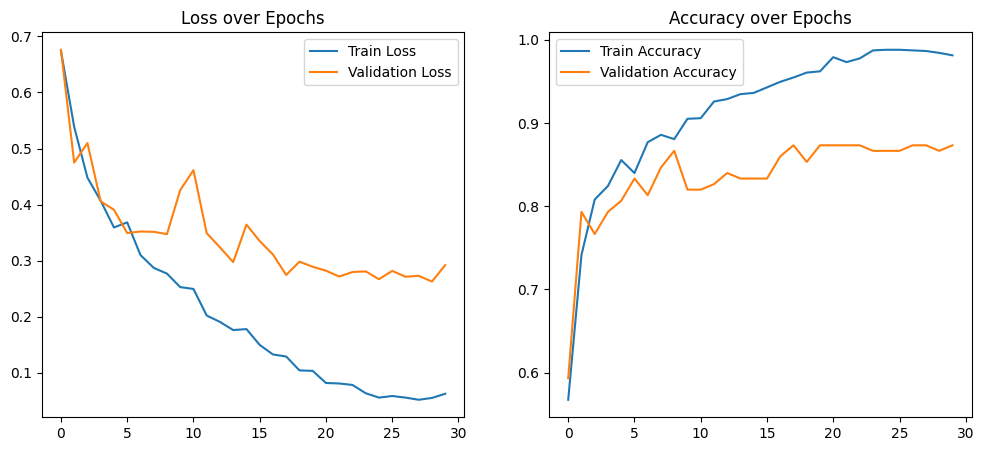

<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()
plt.savefig('loss_acc.png')

In [13]:
# Load model from file
model.load_state_dict(torch.load("./waterfall_fullres.pth", map_location=device))
model.eval()

# Find misclassified images in the validation set
misclassified_images = []
misclassified_labels = []
misclassified_preds = []
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu())
                misclassified_preds.append(predicted[i].cpu())


# Save misclassified images to folder
misclassified_dir = 'misclassified_images'
os.makedirs(misclassified_dir, exist_ok=True)
for idx, (img, true_label, pred_label) in enumerate(zip(misclassified_images, misclassified_labels, misclassified_preds)):
    img_np = img.squeeze().numpy()
    plt.imsave(os.path.join(misclassified_dir, f'misclassified_{idx}_true_{true_label}_pred_{pred_label}.png'), img_np, cmap='gray')

100%|██████████| 10/10 [00:08<00:00,  1.21it/s]


In [14]:
import shutil

output_filename = 'misclassified_images'
shutil.make_archive(output_filename, 'zip', misclassified_dir)
print(f"Compressed '{misclassified_dir}' into '{output_filename}.zip'")

Compressed 'misclassified_images' into 'misclassified_images.zip'
